In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from scipy.stats import pearsonr


In [2]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)
var='pr';units='mm/month'
nx=ny=15

36 41 67 78


In [3]:
season_list = ["DJF","MAM","JJA","SON"]

In [4]:
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/'
plotsDir='/bettik/PROJECTS/pr-regional-climate/fainx/figures/'

In [7]:
##model 1
model1='MAR'
res1=str('7kmx7km')

sourceData1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRp/spin2/work/monthly/'
dsM_ME= xr.open_dataset(sourceData1+'ME_mon_MARv3.14_ER5_spin2_GRp_1980-2024.nc')['ME']

dsM_ME=dsM_ME[:,ny:-ny,nx:-nx].sel(TIME=slice(str(iyr),str(fyr)))

dsM_ME.shape

(540, 0, 52, 116)

In [8]:
dsM_ME()


<xarray.DataArray 'ME' (TIME: 540, SECTOR1_1: 0, Y: 52, X: 116)> Size: 0B
[0 values with dtype=float32]
Coordinates:
  * TIME       (TIME) datetime64[ns] 4kB 1980-01-16T12:00:00 ... 2024-12-16T1...
  * X          (X) float32 464B -399.0 -392.0 -385.0 ... 392.0 399.0 406.0
  * Y          (Y) float32 208B -175.0 -168.0 -161.0 ... 168.0 175.0 182.0
  * SECTOR1_1  (SECTOR1_1) float32 0B 
Attributes:
    long_name:     Meltwater production
    units:         mmWE/day
    cell_methods:  TIME: sum
    history:       From ICE.p78.1980.01.01-31

In [99]:
#1980-1989
dsM_SF_1980=dsM_SF.sel(TIME=slice(str(iyr),str(iyr+9)))
dsM_RF_1980=dsM_RF.sel(TIME=slice(str(iyr),str(iyr+9)))

dsM_SF_1980_season = dsM_SF_1980.groupby('TIME.season').mean(dim='TIME')
dsM_RF_1980_season = dsM_RF_1980.groupby('TIME.season').mean(dim='TIME')

In [100]:
#1990-1999
dsM_SF_1990=dsM_SF.sel(TIME=slice(str(iyr+10),str(iyr+19)))
dsM_RF_1990=dsM_RF.sel(TIME=slice(str(iyr+10),str(iyr+19)))

dsM_SF_1990_season = dsM_SF_1990.groupby('TIME.season').mean(dim='TIME')
dsM_RF_1990_season = dsM_RF_1990.groupby('TIME.season').mean(dim='TIME')

In [101]:
#2000-2009
dsM_SF_2000=dsM_SF.sel(TIME=slice(str(iyr+20),str(iyr+29)))
dsM_RF_2000=dsM_RF.sel(TIME=slice(str(iyr+20),str(iyr+29)))

dsM_SF_2000_season = dsM_SF_2000.groupby('TIME.season').mean(dim='TIME')
dsM_RF_2000_season = dsM_RF_2000.groupby('TIME.season').mean(dim='TIME')

In [102]:
#2010-2019
dsM_SF_2010=dsM_SF.sel(TIME=slice(str(iyr+30),str(iyr+39)))
dsM_RF_2010=dsM_RF.sel(TIME=slice(str(iyr+30),str(iyr+39)))

dsM_SF_2010_season = dsM_SF_2010.groupby('TIME.season').mean(dim='TIME')
dsM_RF_2010_season = dsM_RF_2010.groupby('TIME.season').mean(dim='TIME')

In [103]:
#2014-2024
dsM_SF_2014=dsM_SF.sel(TIME=slice(str(fyr-9),str(fyr)))
dsM_RF_2014=dsM_RF.sel(TIME=slice(str(fyr-9),str(fyr)))

dsM_SF_2014_season = dsM_SF_2014.groupby('TIME.season').mean(dim='TIME')
dsM_RF_2014_season = dsM_RF_2014.groupby('TIME.season').mean(dim='TIME')

In [104]:
dsM_SF_season = dsM_SF.groupby('TIME.season').mean(dim='TIME')
dsM_RF_season = dsM_RF.groupby('TIME.season').mean(dim='TIME')

In [105]:
##model1 - grid
ds1_grid=xr.open_dataset('/home/amoryc/NST.2000.01.01.00.GRp.nc')
field1_SH=ds1_grid['SH'][ny:-ny,nx:-nx]
field1_SH=field1_SH.rename({'x': 'X'})
field1_SH=field1_SH.rename({'y': 'Y'})
#ds1_ICE=ds1_grid['ICE']#[ny:-ny,nx:-nx]
field1_SH.shape

(52, 86)

## Precip annuelle vs alti 1980-2024

In [57]:
SF_mean = dsM_SF.mean(dim='TIME') 
RF_mean = dsM_RF.mean(dim='TIME') 
SF_flat = SF_mean.values.flatten()
RF_flat = RF_mean.values.flatten()
alt_flat = field1_SH.values.flatten()

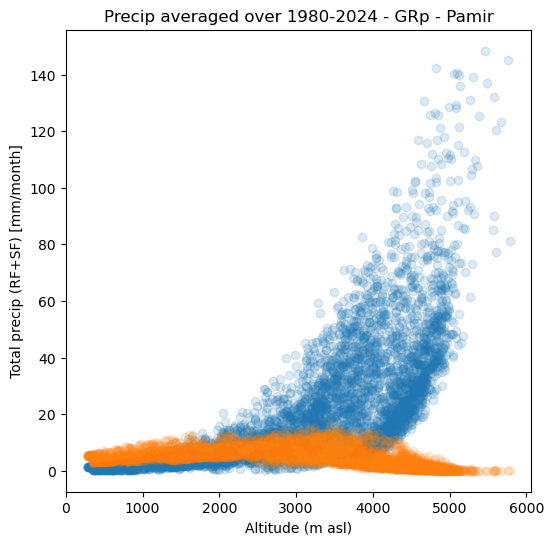

In [58]:
plt.figure(figsize=(6,6))
plt.scatter(alt_flat, SF_flat, alpha=0.15, label='Snow Fall')
plt.scatter(alt_flat, RF_flat, alpha=0.15, label='Rain Fall')
plt.xlabel('Altitude (m asl)')
plt.ylabel('Total precip (RF+SF) [mm/month]')
plt.title('Precip averaged over 1980-2024 - GRp - Pamir')
plt.show()

## Precip saisonniere vs alti 1980-2024

In [112]:
plotname=f'alti_precip_MAR_GRp_{str(iyr)}-{str(fyr)}'

alt_flat = field1_SH.values.flatten()

seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()  # convertir en liste d'axes 1D

for i, season in enumerate(seasons):
    SF_flat = dsM_SF_season[i].values.flatten()
    RF_flat = dsM_RF_season[i].values.flatten()
    
    axes[i].scatter(SF_flat, alpha=0.15, alt_flat, label='Snow Fall')
    axes[i].scatter(RF_flat, alpha=0.15, alt_flat, label='Rain Fall')
    
    axes[i].set_title(season)
    axes[i].set_ylabel("Altitude (m asl)")
    axes[i].set_xlabel("precip [mm/month]")
    axes[i].legend()

# Titre global
fig.suptitle("Montly precip averaged over 1980–2024 - GRp - Pamir", fontsize=14)

plt.tight_layout()
plt.show()

plt.savefig(plotsDir+plotname+'.png', bbox_inches='tight')


SyntaxError: positional argument follows keyword argument (1133691763.py, line 14)

## Precip saisonniere vs alti par décades

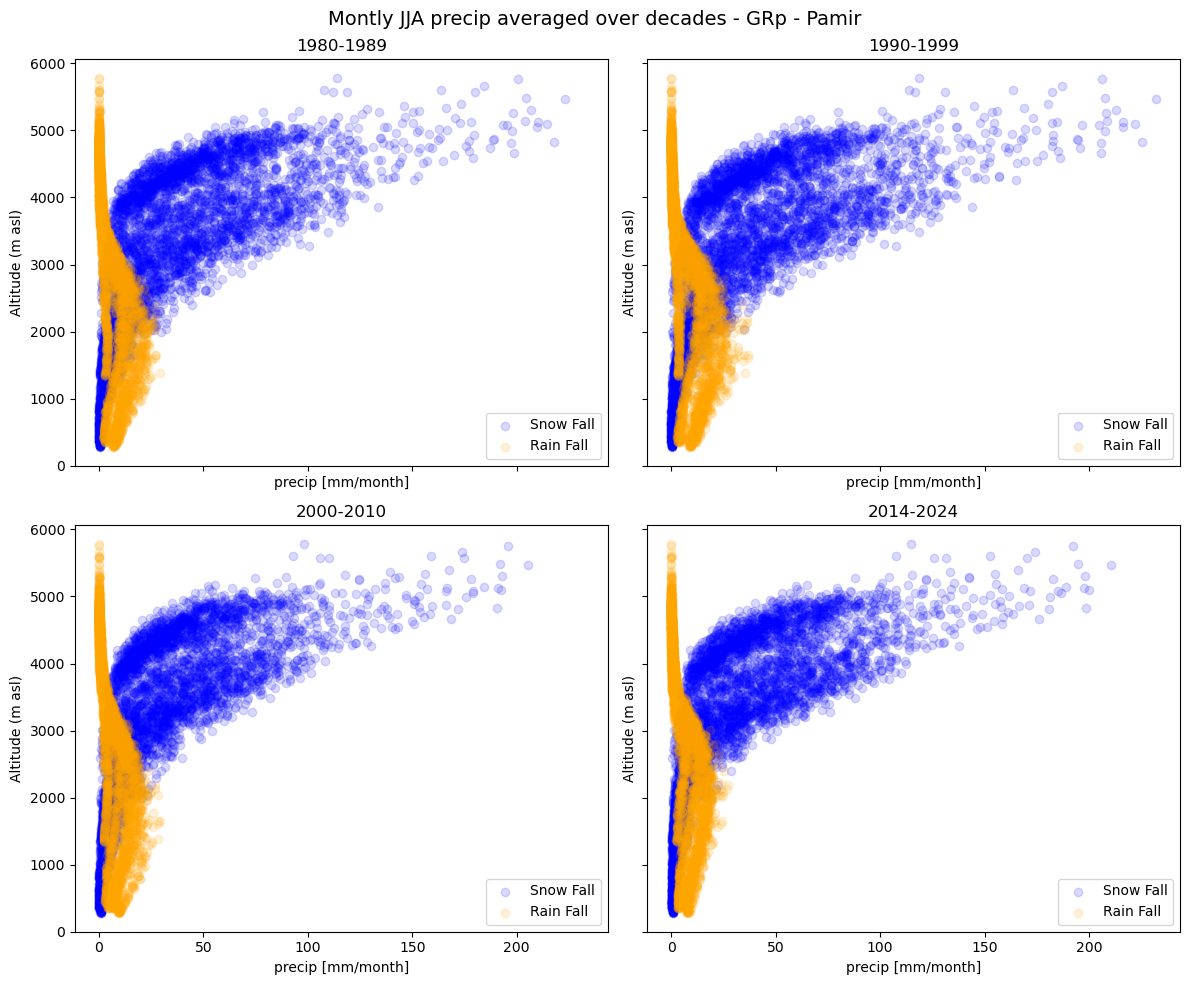

<Figure size 640x480 with 0 Axes>

In [74]:
plotname=f'JJA_alti_precip_MAR_GRp'

alt_flat = field1_SH.values.flatten()

decade = ["1980-1989","1990-1999","2000-2010","2014-2024"]
param = ['1980','1990','2000','2010','2014']

dsM_SF_dic = {
    "1980": dsM_SF_1980_season[2],
    "1990": dsM_SF_1990_season[2],
    "2000": dsM_SF_2000_season[2],
    "2010": dsM_SF_2010_season[2],
    "2014": dsM_SF_2014_season[2],
}
dsM_RF_dic = {
    "1980": dsM_RF_1980_season[2],
    "1990": dsM_RF_1990_season[2],
    "2000": dsM_RF_2000_season[2],
    "2010": dsM_RF_2010_season[2],
    "2014": dsM_RF_2014_season[2],
}


fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()  # convertir en liste d'axes 1D

for i, season in enumerate(decade):
    key = param[i]
    
    axes[i].scatter(dsM_SF_dic[key].values.flatten(), alt_flat, alpha=0.15, label='Snow Fall', color='blue')
    axes[i].scatter(dsM_RF_dic[key].values.flatten(), alt_flat, alpha=0.15, label='Rain Fall', color='orange') 
    axes[i].set_title(decade[i])
    axes[i].set_ylabel("Altitude (m asl)")
    axes[i].set_xlabel("precip [mm/month]")
    axes[i].legend()

# Titre global
fig.suptitle("Montly JJA precip averaged over decades - GRp - Pamir", fontsize=14)

plt.tight_layout()
plt.show()

plt.savefig(plotsDir+plotname+'.png', bbox_inches='tight')

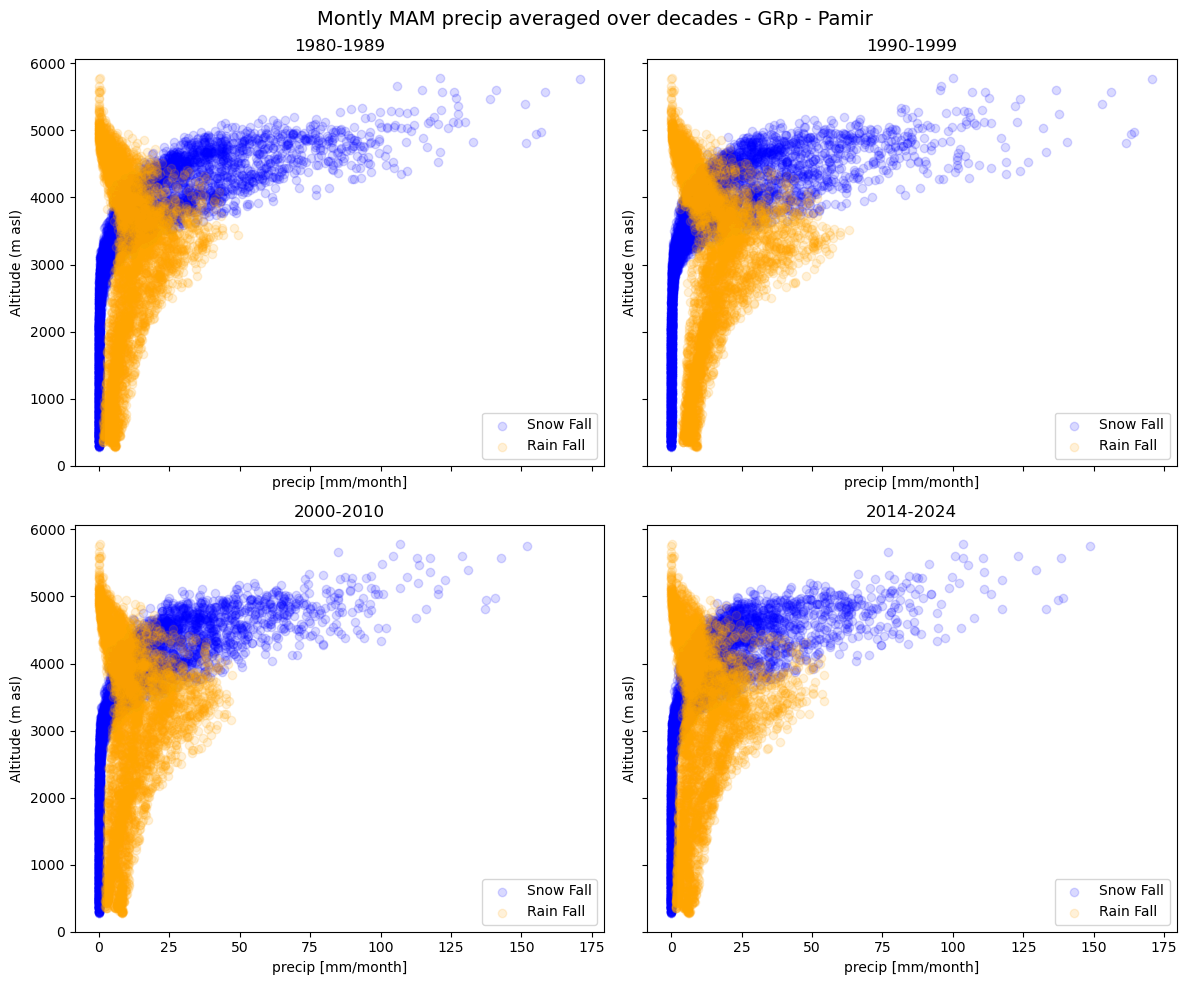

<Figure size 640x480 with 0 Axes>

In [73]:
plotname=f'MAM_alti_precip_MAR_GRp'

alt_flat = field1_SH.values.flatten()

decade = ["1980-1989","1990-1999","2000-2010","2014-2024"]
param = ['1980','1990','2000','2010','2014']

dsM_SF_dic = {
    "1980": dsM_SF_1980_season[1],
    "1990": dsM_SF_1990_season[1],
    "2000": dsM_SF_2000_season[1],
    "2010": dsM_SF_2010_season[1],
    "2014": dsM_SF_2014_season[1],
}
dsM_RF_dic = {
    "1980": dsM_RF_1980_season[1],
    "1990": dsM_RF_1990_season[1],
    "2000": dsM_RF_2000_season[1],
    "2010": dsM_RF_2010_season[1],
    "2014": dsM_RF_2014_season[1],
}


fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()  # convertir en liste d'axes 1D

for i, season in enumerate(decade):
    key = param[i]
    
    axes[i].scatter(dsM_SF_dic[key].values.flatten(), alt_flat, alpha=0.15, label='Snow Fall', color='blue')
    axes[i].scatter(dsM_RF_dic[key].values.flatten(), alt_flat,  alpha=0.15, label='Rain Fall', color='orange') 
    axes[i].set_title(decade[i])
    axes[i].set_ylabel("Altitude (m asl)")
    axes[i].set_xlabel("precip [mm/month]")
    axes[i].legend()

# Titre global
fig.suptitle("Montly MAM precip averaged over decades - GRp - Pamir", fontsize=14)

plt.tight_layout()
plt.show()

plt.savefig(plotsDir+plotname+'.png', bbox_inches='tight')

## Vertical precip profiles

In [81]:
elev_bins = np.arange(0, np.max(alt_flat) + 250, 250)
elev_bin_labels = (elev_bins[:-1] + elev_bins[1:]) / 2

/tmp/ipykernel_41838/3154348357.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
/tmp/ipykernel_41838/3154348357.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
/tmp/ipykernel_41838/3154348357.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')[

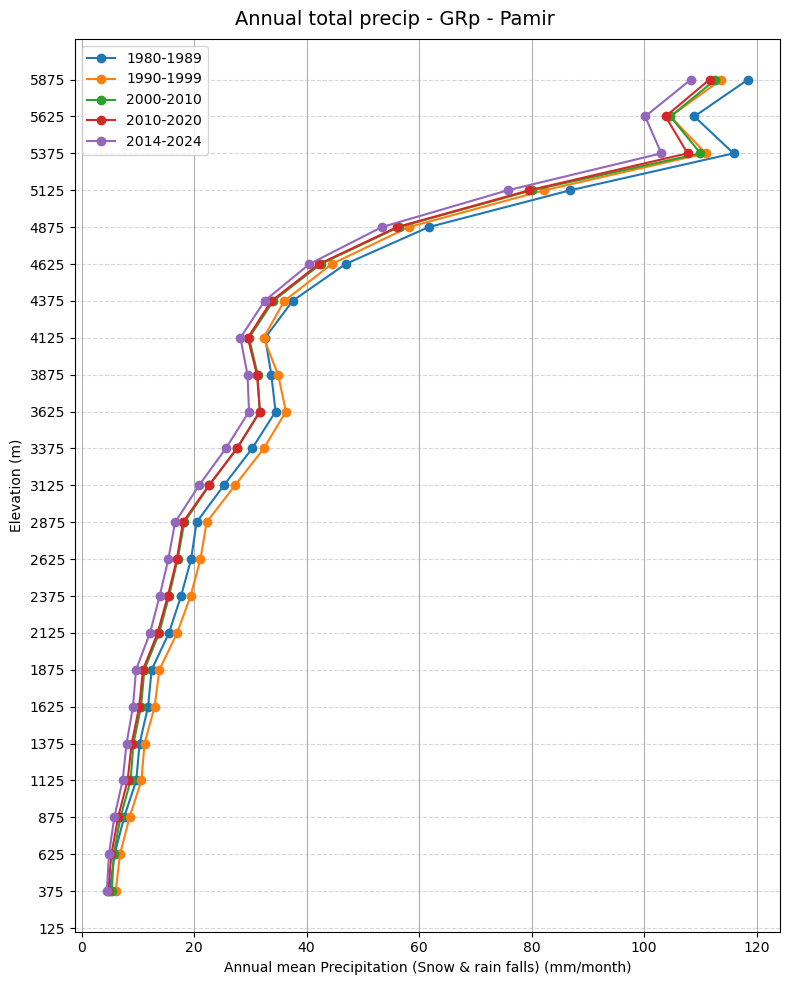

In [120]:
## Snow Fall + Rain Fall

dsList=[dsM_RF_1980+dsM_SF_1980,
        dsM_RF_1990+dsM_SF_1990,
       dsM_RF_2000+dsM_SF_2000,
        dsM_RF_2010+dsM_SF_2010,
       dsM_RF_2014+dsM_SF_2014,
       ]

mean_precip_by_elev_List=[]

for elem in dsList:
    precip_flat = elem.mean('TIME').values.flatten()
    df = pd.DataFrame({'elevation': alt_flat, 'precip': precip_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
    mean_precip_by_elev_List.append(mean_precip_by_elev)    

#####################################################################

decade = ["1980-1989","1990-1999","2000-2010","2010-2020","2014-2024"]

fig=plt.figure(figsize=(8, 10))

# plt.plot(mean_precip_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan', label=decade[0])

for i in np.arange(0,len(dsList[0:]),1):                
    plt.plot(mean_precip_by_elev_List[i].values,elev_bin_labels, marker='o', label=decade[i])#,color=colorList[i-1])
         # label=modelList[1+i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.ylabel('Elevation (m)')
plt.xlabel('Annual mean Precipitation (Snow & rain falls) (mm/month)')
plt.legend()

fig.suptitle("Annual total precip - GRp - Pamir", fontsize=14)

plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_41838/403277366.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
/tmp/ipykernel_41838/403277366.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
/tmp/ipykernel_41838/403277366.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['pr

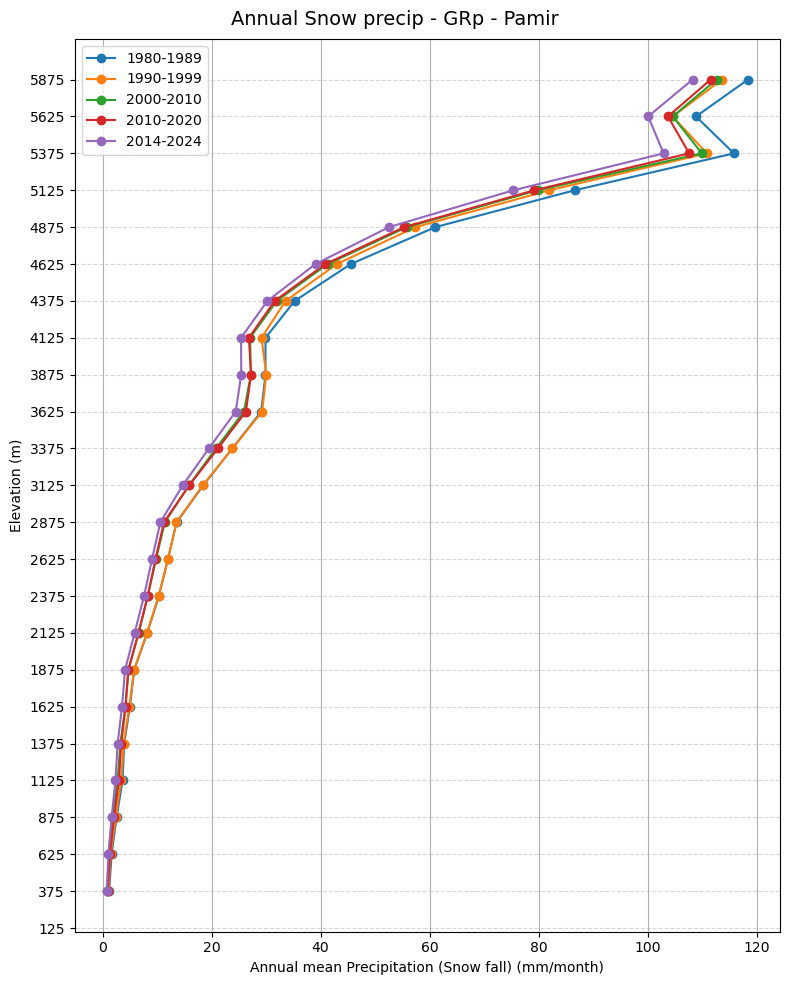

In [119]:
## Only Snow Fall

dsList=[dsM_SF_1980,
        dsM_SF_1990,
       dsM_SF_2000,
        dsM_SF_2010,
       dsM_SF_2014,
       ]

mean_precip_by_elev_List=[]

for elem in dsList:
    precip_flat = elem.mean('TIME').values.flatten()
    df = pd.DataFrame({'elevation': alt_flat, 'precip': precip_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
    mean_precip_by_elev_List.append(mean_precip_by_elev)    

#####################################################################

decade = ["1980-1989","1990-1999","2000-2010","2010-2020","2014-2024"]

fig=plt.figure(figsize=(8, 10))

# plt.plot(mean_precip_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan', label=decade[0])

for i in np.arange(0,len(dsList[0:]),1):                
    plt.plot(mean_precip_by_elev_List[i].values,elev_bin_labels, marker='o', label=decade[i])#,color=colorList[i-1])
         # label=modelList[1+i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.ylabel('Elevation (m)')
plt.xlabel('Annual mean Precipitation (Snow fall) (mm/month)')
fig.suptitle("Annual Snow precip - GRp - Pamir", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_41838/1519036178.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
/tmp/ipykernel_41838/1519036178.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
/tmp/ipykernel_41838/1519036178.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')[

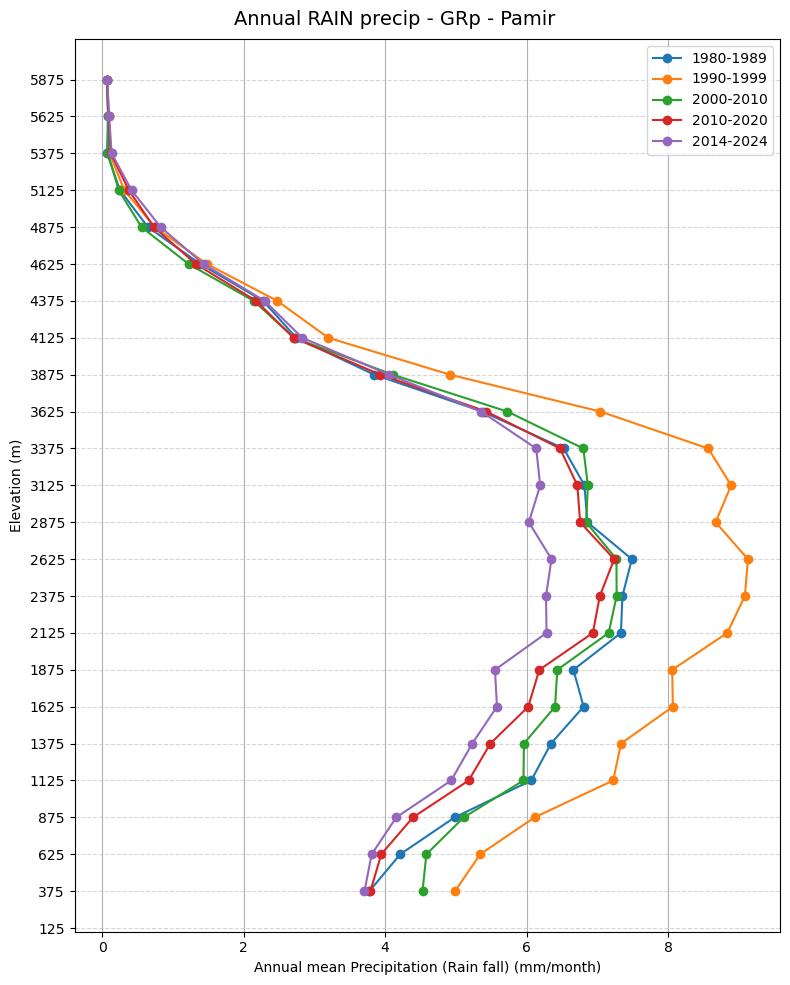

In [121]:
## Only Rain Fall

dsList=[dsM_RF_1980,
        dsM_RF_1990,
       dsM_RF_2000,
        dsM_RF_2010,
       dsM_RF_2014,
       ]

mean_precip_by_elev_List=[]

for elem in dsList:
    precip_flat = elem.mean('TIME').values.flatten()
    df = pd.DataFrame({'elevation': alt_flat, 'precip': precip_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
    mean_precip_by_elev_List.append(mean_precip_by_elev)    

#####################################################################

decade = ["1980-1989","1990-1999","2000-2010","2010-2020","2014-2024"]

fig=plt.figure(figsize=(8, 10))

for i in np.arange(0,len(dsList[0:]),1):                
    plt.plot(mean_precip_by_elev_List[i].values,elev_bin_labels, marker='o', label=decade[i])#,color=colorList[i-1])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.ylabel('Elevation (m)')
plt.xlabel('Annual mean Precipitation (Rain fall) (mm/month)')
fig.suptitle("Annual RAIN precip - GRp - Pamir", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_41838/1585103782.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
/tmp/ipykernel_41838/1585103782.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
/tmp/ipykernel_41838/1585103782.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')[

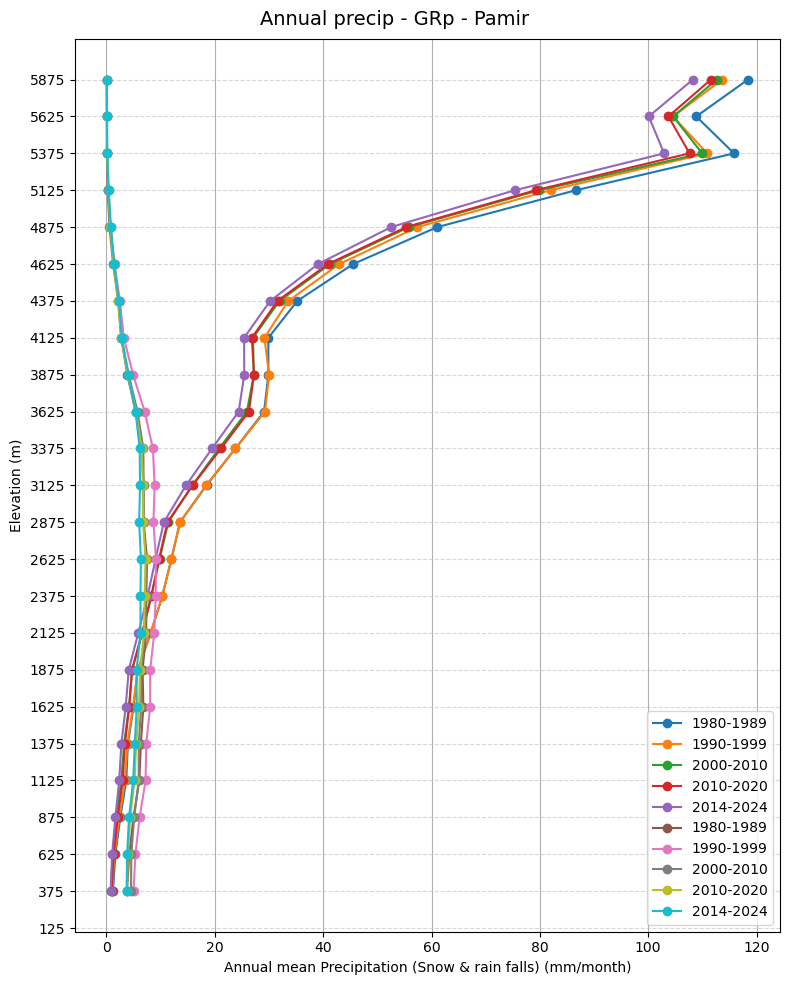

In [122]:
## ALL

dsList=[dsM_SF_1980,
        dsM_SF_1990,
       dsM_SF_2000,
        dsM_SF_2010,
       dsM_SF_2014,
        dsM_RF_1980,
        dsM_RF_1990,
       dsM_RF_2000,
        dsM_RF_2010,
       dsM_RF_2014,
       ]

mean_precip_by_elev_List=[]

for elem in dsList:
    precip_flat = elem.mean('TIME').values.flatten()
    df = pd.DataFrame({'elevation': alt_flat, 'precip': precip_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
    mean_precip_by_elev_List.append(mean_precip_by_elev)    

#####################################################################

decade = ["1980-1989","1990-1999","2000-2010","2010-2020","2014-2024","1980-1989","1990-1999","2000-2010","2010-2020","2014-2024"]

fig=plt.figure(figsize=(8, 10))

# plt.plot(mean_precip_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan', label=decade[0])

for i in np.arange(0,len(dsList[0:]),1):                
    plt.plot(mean_precip_by_elev_List[i].values,elev_bin_labels, marker='o', label=decade[i])#,color=colorList[i-1])
         # label=modelList[1+i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.ylabel('Elevation (m)')
plt.xlabel('Annual mean Precipitation (Snow & rain falls) (mm/month)')
fig.suptitle("Annual precip - GRp - Pamir", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_41838/3894588648.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
/tmp/ipykernel_41838/3894588648.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
/tmp/ipykernel_41838/3894588648.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_precip_by_elev = df.groupby('elev_bin')[

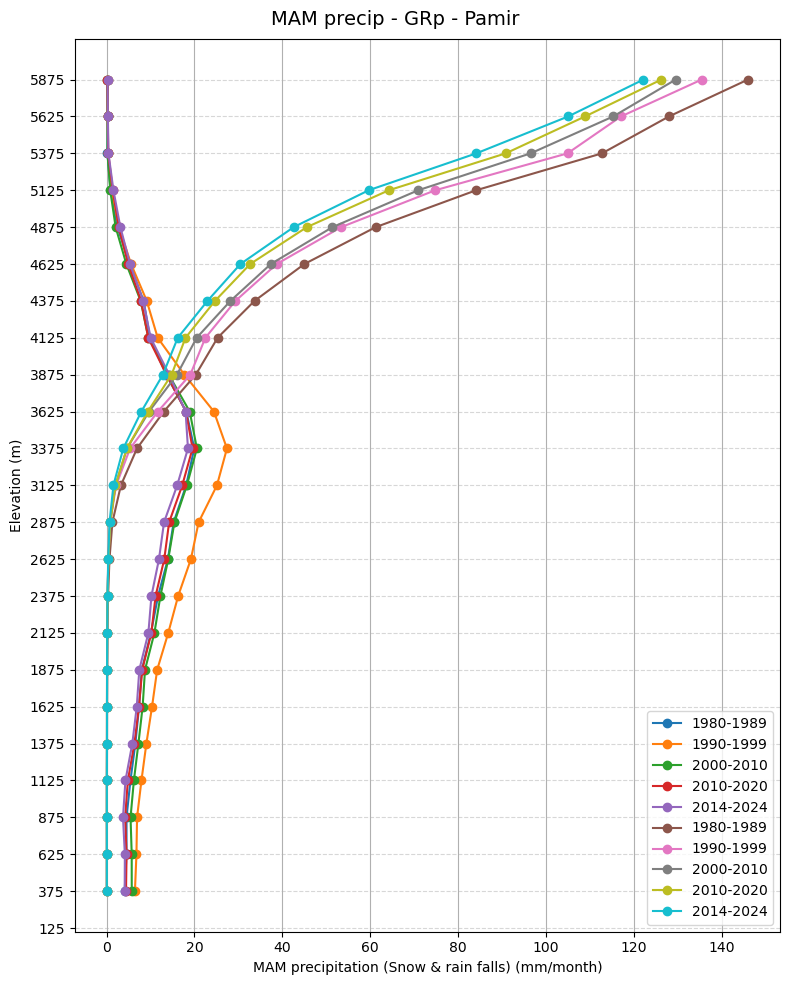

In [123]:
## ALL for MAM

dsList=[dsM_RF_1980_season[1],
        dsM_RF_1990_season[1],
       dsM_RF_2000_season[1],
        dsM_RF_2010_season[1],
       dsM_RF_2014_season[1],
        dsM_SF_1980_season[1],
        dsM_SF_1990_season[1],
       dsM_SF_2000_season[1],
        dsM_SF_2010_season[1],
       dsM_SF_2014_season[1],
       ]

mean_precip_by_elev_List=[]

for elem in dsList:
    precip_flat = elem.values.flatten()
    df = pd.DataFrame({'elevation': alt_flat, 'precip': precip_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
    mean_precip_by_elev_List.append(mean_precip_by_elev)    

#####################################################################

decade = ["1980-1989","1990-1999","2000-2010","2010-2020","2014-2024","1980-1989","1990-1999","2000-2010","2010-2020","2014-2024"]

fig=plt.figure(figsize=(8, 10))

# plt.plot(mean_precip_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan', label=decade[0])

for i in np.arange(0,len(dsList[0:]),1):                
    plt.plot(mean_precip_by_elev_List[i].values,elev_bin_labels, marker='o', label=decade[i])#,color=colorList[i-1])
         # label=modelList[1+i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.ylabel('Elevation (m)')
plt.xlabel('MAM precipitation (Snow & rain falls) (mm/month)')
fig.suptitle("MAM precip - GRp - Pamir", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
####
model3='aphro'
res3=str('0.25°x0.25°')

fileName3='APHRO_mon_MA_025deg_V1101_EXR1.1951-2015.nc'
ds3 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/aphro/monthly/'
                      +fileName3,decode_times=False)['precip']
start_date = pd.Timestamp('1951-01-01')
# Create new time index
nmonths = ds3.time.size
time_new = pd.date_range(start=start_date, periods=nmonths, freq='MS')  # 'MS' = Month Start
# Replace time in dataset
ds3['time'] = time_new

ds3=ds3.rename({'latitude':'lat','longitude':'lon'})
field3_mm_day=dom.field_dom(ds3,domain)
field3_mm_day=field3_mm_day.sel(time=slice(str(iyr),str(fyr)))

# Convert mm/day to mm/month
days_in_month = field3_mm_day['time'].dt.days_in_month
field3= field3_mm_day * days_in_month

field3.shape

(420, 20, 44)

In [ ]:
plotname=f'alti_precip_MAR_GRp_{str(iyr)}-{str(fyr)}'

alt_flat = field1_SH.values.flatten()

seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()  # convertir en liste d'axes 1D

for i, season in enumerate(seasons):
    SF_flat = dsM_SF_season[i].values.flatten()
    RF_flat = dsM_RF_season[i].values.flatten()
    
    axes[i].scatter(alt_flat, SF_flat, alpha=0.15, label='Snow Fall')
    axes[i].scatter(alt_flat, RF_flat, alpha=0.15, label='Rain Fall')
    
    axes[i].set_title(season)
    axes[i].set_xlabel("Altitude (m asl)")
    axes[i].set_ylabel("precip [mm/month]")
    axes[i].legend()

# Titre global
fig.suptitle("Montly precip averaged over 1980–2024 - GRp - Pamir", fontsize=14)

plt.tight_layout()
plt.show()

plt.savefig(plotsDir+plotname+'.png', bbox_inches='tight')


In [9]:
##model 3
ds3_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_aphro.nc')['elevation']
field3_SH=dom.field_dom(ds3_SH,domain)
field3_SH.shape

(20, 44)

In [10]:
###model 4
model4='gpcp'
res4=str('1.0°x1.0°')

fileName4='precip_mon.gpcp_v2020_1891_2019_10.nc'
ds4= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/'
                     +model4+'/'+fileName4)['precip']
print(ds4.attrs) 
ds4=dom.reversing_lat(ds4)
#units in mm/month -> mm/day
field4=dom.field_dom(ds4,domain)

#month_length = field40.time.dt.days_in_month
#
#field4=field40/month_length
field4=field4.sel(time=slice(str(iyr),str(fyr)))
field4.shape

{'long_name': 'gpcc full data monthly product version 2020, precipitation per grid', 'units': 'mm/month', 'code': np.int32(20), 'institution': 'DWD'}


(420, 5, 11)

In [11]:
ds4_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_gpcp.nc')['elevation']
field4_SH=dom.field_dom(ds4_SH,domain)
field4_SH.shape

(5, 11)

In [12]:
##model5
model5='cru'
res5=str('0.5°x0.5°')

fileName5='cru_ts4.05.1901.2020.pre.dat.nc'
ds5 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/'+model5+'/'+fileName5)['pre']
print(ds5.attrs)

#units in mm/month -> mm/day
field5=dom.field_dom(ds5,domain)
#month_length5 = field50.time.dt.days_in_month
#
#field5=field50/month_length5
field5=field5.sel(time=slice(str(iyr),str(fyr)))
field5.shape

{'long_name': 'precipitation', 'units': 'mm/month', 'correlation_decay_distance': np.float32(450.0)}


(420, 10, 22)

In [13]:
##
ds5_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_cru_hma_grid.nc')['elevation']
field5_SH=dom.field_dom(ds5_SH,domain)
field5_SH.shape

(10, 22)

In [14]:
model6='chirps'
res6='0.05°x0.05°'
fileName6='chirps-v2.0.monthly.nc'
ds6 = xr.open_dataset(sourceData+model6+'/'+fileName6)['precip']
ds6=ds6.rename({'latitude':'lat','longitude':'lon'})
field6=dom.field_dom(ds6,domain)


print(field6.shape)

(531, 100, 220)


In [15]:
##
ds6_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_chirps_hma_grid.nc')['elevation']
field6_SH=dom.field_dom(ds6_SH,domain)
field6_SH.shape

(100, 220)

In [16]:
model7='HARv2'
res7='10kmx10km'
#variable='prcp'
fileName7='HARv2_mon_d10km_d_2d_prcp_1980-2023.nc'
ds7_raw0= xr.open_dataset(sourceData+'/'+model7+'/'+fileName7)['prcp']
ds7_raw=ds7_raw0*24 #mm/h
# Calculate days in each month
days_in_month7= ds7_raw['time'].dt.days_in_month
# Convert to mm/month
ds7= ds7_raw* days_in_month7
def xy_sel_dom(ds,domain):
    latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

# Apply mask (non-NaN where the condition is True)
#hgt_subset = hgt.where(mask, drop=True)
field7=xy_sel_dom(ds7.sel(time=slice(str(iyr),str(fyr))),domain)

time
lon
lat
west_east
south_north


In [17]:
fileName7_grF='HARv2_d10km_static_hgt.nc'
##fileName_grM='NST.2000.01.01.00.GRa_Mera.nc_ICEmask'
ds7_grM= xr.open_dataset(sourceData+'/'+model7+'/'+fileName7_grF)
ds7SH=ds7_grM['hgt'][0,:,:]
#dsSH
field7_SH=xy_sel_dom(ds7SH,domain)


time
west_east
south_north
lon
lat


In [22]:
dsList=[field1,
        field3,field4,field5,
        field6,field7]
modelList=[model1,
           model3,model4,model5,
           model6,model7]
resList=[res1,
         res3,res4,res5,
         res6,res7]
nameList=list(zip(modelList,resList))

In [23]:
print(nameList)

[('MAR', '7kmx7km'), ('aphro', '0.25°x0.25°'), ('gpcp', '1.0°x1.0°'), ('cru', '0.5°x0.5°'), ('chirps', '0.05°x0.05°'), ('HARv2', '10kmx10km')]


In [18]:
#valsList_DJF = [climb.seasonal_selection(elem, 'DJF', iyr, fyr)[0] for elem in dsList]
#valsList_MAM= [climb.seasonal_selection(elem, 'MAM', iyr, fyr)[0] for elem in dsList]
#valsList_JJA= [climb.seasonal_selection(elem, 'JJA', iyr, fyr)[0] for elem in dsList]
#valsList_SON = [climb.seasonal_selection(elem, 'SON', iyr, fyr)[0] for elem in dsList]


In [24]:
len(dsList)

6

In [7]:
elevList=[field1_SH]
# elevList=[field1_SH,field3_SH,field4_SH,field5_SH,field6_SH,field7_SH]
print(len(elevList))

1


In [8]:
colors=['b','orange', 'pink', 'red', 'green', 'black']

In [9]:
level_bounds = [(0, 2500), (2500, 4500), (4500, 5500), (5500, 7500)]
level_bounds[0][1]

2500

In [10]:
level_bounds = [(0, 2500), (2500, 4500), (4500, 5500), (5500, 7500)]
maskList = []

for elev in elevList:
    masks_per_field = []
    for lev_min, lev_max in level_bounds:
        mask = (elev >= lev_min) & (elev < lev_max)
        masks_per_field.append(mask)
    maskList.append(masks_per_field)

# Check: number of datasets and levels per dataset
print(len(maskList))           # Should be 6 (number of datasets)
print(len(maskList[0]))

1
4


In [11]:
maskList_field1 = []
for lev_min, lev_max in level_bounds:
    mask = (field1_SH >= lev_min) & (field1_SH < lev_max)
    maskList_field1.append(mask)

# maskList_field3 = []
# for lev_min, lev_max in level_bounds:
#     mask = (field3_SH >= lev_min) & (field3_SH < lev_max)
#     maskList_field3.append(mask)

# maskList_field4 = []
# for lev_min, lev_max in level_bounds:
#     mask = (field4_SH >= lev_min) & (field4_SH < lev_max)
#     maskList_field4.append(mask)

# maskList_field5 = []
# for lev_min, lev_max in level_bounds:
#     mask = (field5_SH >= lev_min) & (field5_SH < lev_max)
#     maskList_field5.append(mask)

# maskList_field6 = []
# for lev_min, lev_max in level_bounds:
#     mask = (field6_SH >= lev_min) & (field6_SH < lev_max)
#     maskList_field6.append(mask)
    
# maskList_field7 = []
# for lev_min, lev_max in level_bounds:
#     mask = (field7_SH >= lev_min) & (field7_SH < lev_max)
#     maskList_field7.append(mask)

In [12]:
field1_season = field1.groupby('time.season').mean('time')
# field3_season = field3.groupby('time.season').mean('time')
# field4_season = field4.groupby('time.season').mean('time')
# field5_season = field5.groupby('time.season').mean('time')
# field6_season = field6.groupby('time.season').mean('time')
# field7_season = field7.groupby('time.season').mean('time')

In [13]:
def compute_mean_for_masks(field_season, mask_list, season, dims):
    mean_vals = []
    for mask in mask_list:
        masked = field_season.sel(season=season).where(mask.values)
        for dim in dims:
            masked = masked.mean(dim)
        mean_vals.append(masked)
    return mean_vals

# Then apply it like this:
mean_vals_field1_JJA = compute_mean_for_masks(field1_season, maskList_field1, 'JJA', ['X', 'Y'])
# mean_vals_field3_JJA = compute_mean_for_masks(field3_season, maskList_field3, 'JJA', ['lon', 'lat'])
# mean_vals_field4_JJA = compute_mean_for_masks(field4_season, maskList_field4, 'JJA', ['lon', 'lat'])
# mean_vals_field5_JJA = compute_mean_for_masks(field5_season, maskList_field5, 'JJA', ['lon', 'lat'])
# mean_vals_field6_JJA = compute_mean_for_masks(field6_season, maskList_field6, 'JJA', ['lon', 'lat'])
# mean_vals_field7_JJA = compute_mean_for_masks(field7_season, maskList_field7, 'JJA', ['south_north', 'west_east'])

In [14]:
# Then apply it like this:
mean_vals_field1_DJF = compute_mean_for_masks(field1_season, maskList_field1, 'DJF', ['X', 'Y'])
# mean_vals_field3_DJF = compute_mean_for_masks(field3_season, maskList_field3, 'DJF', ['lon', 'lat'])
# mean_vals_field4_DJF = compute_mean_for_masks(field4_season, maskList_field4, 'DJF', ['lon', 'lat'])
# mean_vals_field5_DJF = compute_mean_for_masks(field5_season, maskList_field5, 'DJF', ['lon', 'lat'])
# mean_vals_field6_DJF = compute_mean_for_masks(field6_season, maskList_field6, 'DJF', ['lon', 'lat'])
# mean_vals_field7_DJF = compute_mean_for_masks(field7_season, maskList_field7, 'DJF', ['south_north', 'west_east'])

In [15]:
mean_vals_field1_MAM = compute_mean_for_masks(field1_season, maskList_field1, 'MAM', ['X', 'Y'])
# mean_vals_field3_MAM = compute_mean_for_masks(field3_season, maskList_field3, 'MAM', ['lon', 'lat'])
# mean_vals_field4_MAM = compute_mean_for_masks(field4_season, maskList_field4, 'MAM', ['lon', 'lat'])
# mean_vals_field5_MAM = compute_mean_for_masks(field5_season, maskList_field5, 'MAM', ['lon', 'lat'])
# mean_vals_field6_MAM = compute_mean_for_masks(field6_season, maskList_field6, 'MAM', ['lon', 'lat'])
# mean_vals_field7_MAM = compute_mean_for_masks(field7_season, maskList_field7, 'MAM', ['south_north', 'west_east'])


In [16]:
mean_vals_field1_SON = compute_mean_for_masks(field1_season, maskList_field1, 'SON', ['X', 'Y'])
# mean_vals_field3_SON = compute_mean_for_masks(field3_season, maskList_field3, 'SON', ['lon', 'lat'])
# mean_vals_field4_SON = compute_mean_for_masks(field4_season, maskList_field4, 'SON', ['lon', 'lat'])
# mean_vals_field5_SON = compute_mean_for_masks(field5_season, maskList_field5, 'SON', ['lon', 'lat'])
# mean_vals_field6_SON = compute_mean_for_masks(field6_season, maskList_field6, 'SON', ['lon', 'lat'])
# mean_vals_field7_SON = compute_mean_for_masks(field7_season, maskList_field7, 'SON', ['south_north', 'west_east'])

In [35]:
mean_vals_field1_ANN = []
for mask in maskList_field1:
    masked = field1.groupby('time.year').mean('time').mean('year').where(mask.values).mean('X').mean('Y')
    mean_vals_field1_ANN.append(masked)

mean_vals_field3_ANN = []
for mask in maskList_field3:
    masked = field3.groupby('time.year').mean('time').mean('year').where(mask.values).mean('lon').mean('lat')
    mean_vals_field3_ANN.append(masked)

mean_vals_field4_ANN = []
for mask in maskList_field4:
    masked = field4.groupby('time.year').mean('time').mean('year').where(mask.values).mean('lon').mean('lat')
    mean_vals_field4_ANN.append(masked)

mean_vals_field5_ANN = []
for mask in maskList_field5:
    masked = field5.groupby('time.year').mean('time').mean('year').where(mask.values).mean('lon').mean('lat')
    mean_vals_field5_ANN.append(masked)

mean_vals_field6_ANN = []
for mask in maskList_field6:
    masked = field6.groupby('time.year').mean('time').mean('year').where(mask.values).mean('lon').mean('lat')
    mean_vals_field6_ANN.append(masked)

mean_vals_field7_ANN = []
for mask in maskList_field7:
    masked = field7.groupby('time.year').mean('time').mean('year').where(mask.values).mean('south_north').mean('west_east')
    mean_vals_field7_ANN.append(masked)


In [36]:
colorList=['b','orange', 'pink', 'red', 'green', 'black']
markerList=['o','X','X','X','X','X']

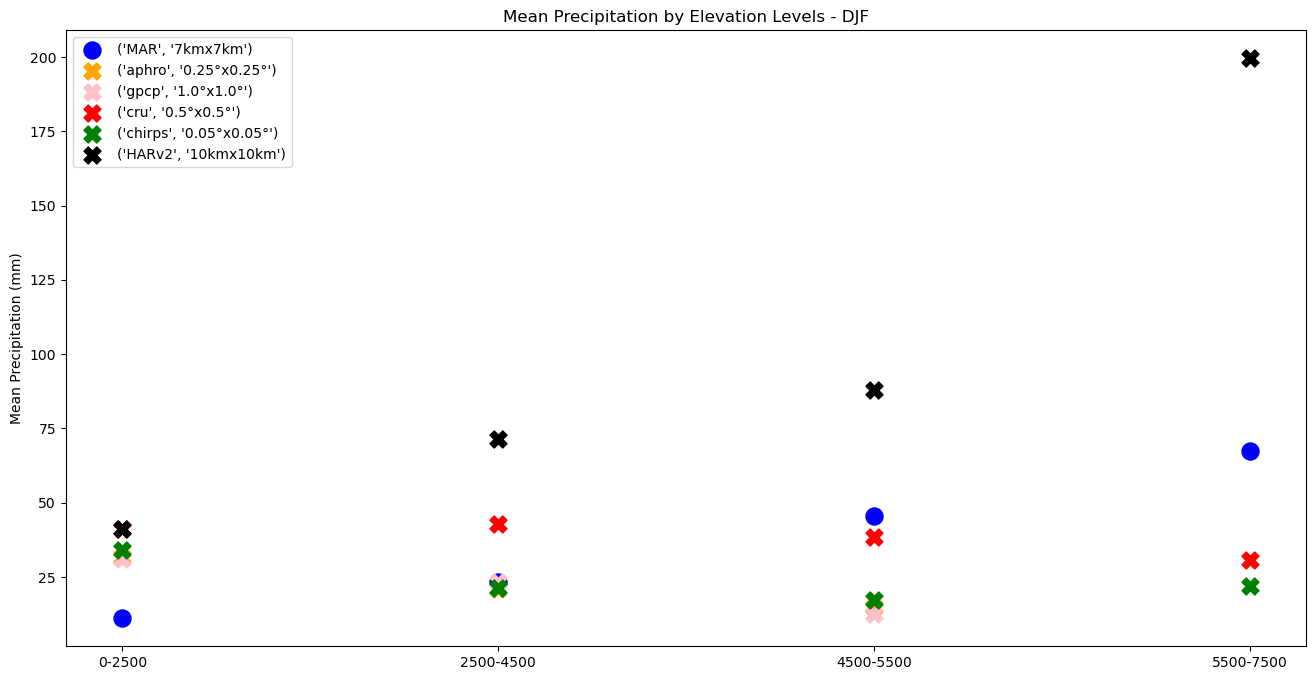

In [37]:
fig, ax = plt.subplots(figsize=(16, 8))

colors = colorList
elev_labels = ['0-2500', '2500-4500', '4500-5500', '5500-7500']

# Lista con las mean_vals para cada dataset
mean_vals_all = [mean_vals_field1_DJF, mean_vals_field3_DJF, mean_vals_field4_DJF,
                 mean_vals_field5_DJF, mean_vals_field6_DJF, mean_vals_field7_DJF]

for i, mean_vals in enumerate(mean_vals_all):
    plt.scatter([0,1,2,3], mean_vals, marker=markerList[i],color=colors[i], s=150, label=nameList[i])

plt.xticks([0,1,2,3], elev_labels)
ax.set_ylabel('Mean Precipitation (mm)')
ax.set_title('Mean Precipitation by Elevation Levels - DJF')
ax.legend()

plt.show()

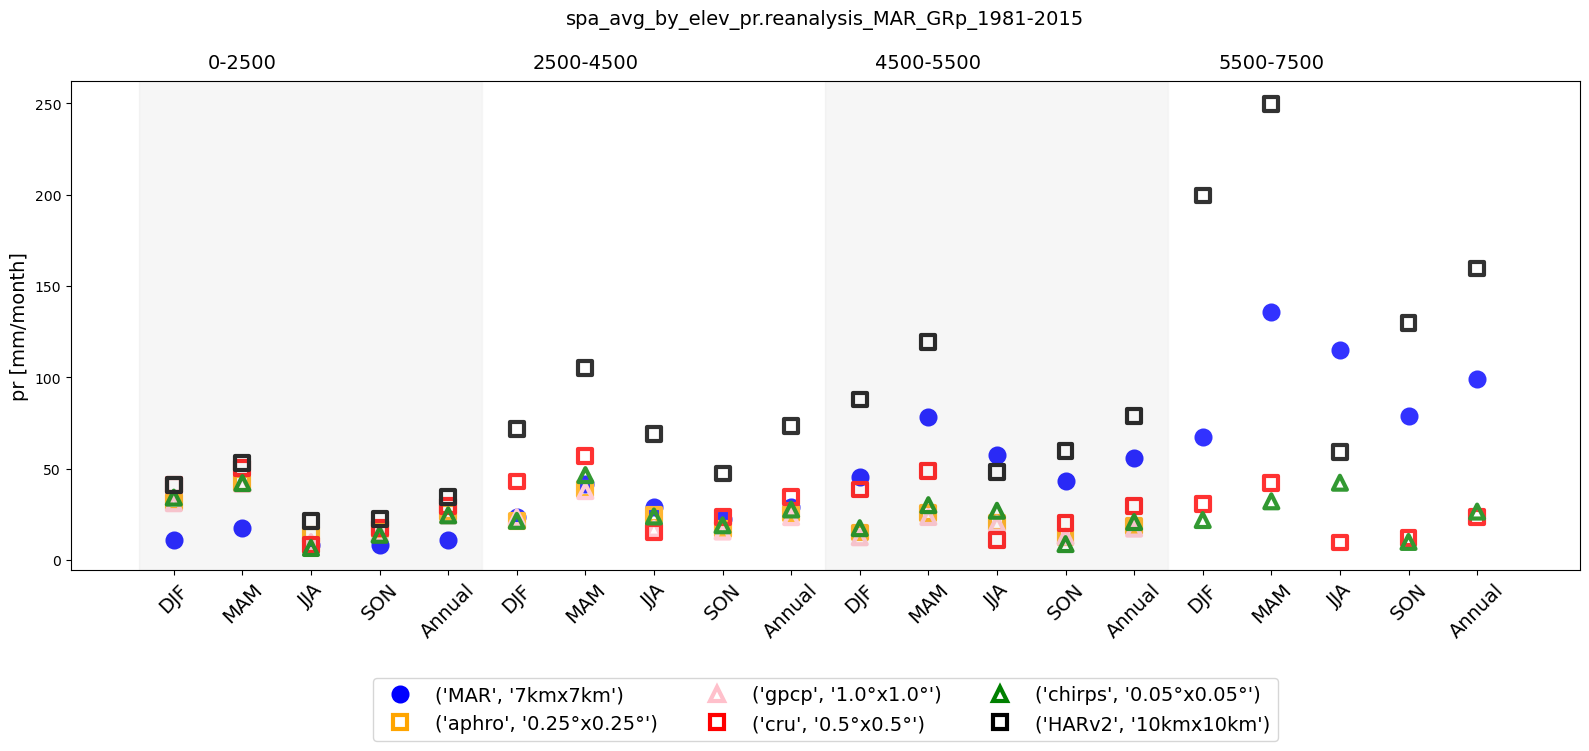

In [47]:
plotname=f'spa_avg_by_elev_{var}.reanalysis_MAR_GRp_{str(iyr)}-{str(fyr)}'

fig, ax = plt.subplots(figsize=(16, 8))
xpos=np.arange(0,20,5)

colorList=['b','orange', 'pink', 'red', 'green', 'black']
markerList=['o','s','^','s','^','s']
faceList=['b','none', 'none', 'none', 'none', 'none']
colors = colorList
elev_labels = ['0-2500', '2500-4500', '4500-5500', '5500-7500']

# Lista con las mean_vals para cada dataset
mean_vals_all_DJF = [mean_vals_field1_DJF, mean_vals_field3_DJF, mean_vals_field4_DJF,
                 mean_vals_field5_DJF, mean_vals_field6_DJF, mean_vals_field7_DJF]

mean_vals_all_MAM = [mean_vals_field1_MAM, mean_vals_field3_MAM, mean_vals_field4_MAM,
                     mean_vals_field5_MAM, mean_vals_field6_MAM, mean_vals_field7_MAM]

mean_vals_all_JJA = [mean_vals_field1_JJA, mean_vals_field3_JJA, mean_vals_field4_JJA,
                     mean_vals_field5_JJA, mean_vals_field6_JJA, mean_vals_field7_JJA]

mean_vals_all_SON = [mean_vals_field1_SON, mean_vals_field3_SON, mean_vals_field4_SON,
                     mean_vals_field5_SON, mean_vals_field6_SON, mean_vals_field7_SON]

mean_vals_all_ANN = [mean_vals_field1_ANN, mean_vals_field3_ANN, mean_vals_field4_ANN,
                     mean_vals_field5_ANN, mean_vals_field6_ANN, mean_vals_field7_ANN]

#for i, mean_vals in enumerate(mean_vals_all_DJF):
#    plt.scatter(xpos, mean_vals, marker=markerList[i],color=colors[i],edgecolor='k',
#                    s=100, label=nameList[i])

for i, mean_vals in enumerate(mean_vals_all_DJF):
    plt.scatter(xpos, mean_vals, marker=markerList[i],facecolors=faceList[i],
                edgecolor=colors[i],
                linewidth=3,
                color=colors[i], s=100, label=nameList[i])

for i, mean_vals in enumerate(mean_vals_all_MAM):
    plt.scatter(xpos+1, mean_vals, marker=markerList[i],facecolors=faceList[i],
                edgecolor=colors[i],
                linewidth=3,
                color=colors[i], s=100, label=nameList[i])
    
for i, mean_vals in enumerate(mean_vals_all_JJA):
    plt.scatter(xpos+2, mean_vals, marker=markerList[i],facecolors=faceList[i],
                edgecolor=colors[i],
                linewidth=3,
                color=colors[i], s=100, label=nameList[i])

for i, mean_vals in enumerate(mean_vals_all_SON):
    plt.scatter(xpos+3, mean_vals, marker=markerList[i],facecolors=faceList[i],
                edgecolor=colors[i],
                linewidth=3,
                color=colors[i], s=100, label=nameList[i])

for i, mean_vals in enumerate(mean_vals_all_ANN):
    plt.scatter(xpos+4, mean_vals, marker=markerList[i],facecolors=faceList[i],
                edgecolor=colors[i],
                linewidth=3,
                color=colors[i], s=100, label=nameList[i])

ax.set_xticks(range(5*4))
ax.set_xticklabels(['DJF','MAM','JJA','SON', 'Annual'] * 4, rotation=45, fontsize=14)
# Background shading every 5 elements
for i in range(0, 20, 5):
    ax.axvspan(i - 0.5, i + 4.5, color='lightgrey' if (i // 5) % 2 == 0 else 'white', alpha=0.2)

# Legend for green and blue
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0],
           marker=markerList[i],
           color='none',                # no connecting line
           markerfacecolor=faceList[i],  # fill color like scatter's facecolors
           markeredgecolor=colors[i],    # edge color same as scatter
           markeredgewidth=3,            # thick edges
           markersize=10,
           label=nameList[i])
    for i in range(len(markerList))
]
ax.legend(
    handles=legend_elements,
    bbox_to_anchor=(0.5, -0.2),  # position below plot
    loc='upper center',
    fontsize=14,
    frameon=True,
    ncol=3
)
ax.set_ylabel(f'{var} [{units}]',fontsize=14)
ax.set_title(plotname,fontsize=14,y=1.1)
#ax.legend()
# Group labels above each triplet
group_labels = elev_labels
for i, label in enumerate(group_labels):
    x_center = i * 5 + 1
    y_pos = ax.get_ylim()[1] * 1.02
    ax.text(x_center, y_pos, label, ha='center', va='bottom', fontsize=14)
plt.tight_layout()

# Save figure (including legend outside)
plt.savefig(plotsDir+plotname+'.png', bbox_inches='tight')

plt.show()

In [48]:
def compute_mean_for_masks_avg(field, mask_list, season, dims):
    mean_vals = []
    for mask in mask_list:
        masked = field.where(mask.values)
        for dim in dims:
            masked = masked.mean(dim)
        mean_vals.append(masked)
    return mean_vals

# Then apply it like this:
mean_vals_avg_field1_JJA = compute_mean_for_masks_avg(field1, maskList_field1, 'JJA', ['X', 'Y'])
mean_vals_avg_field3_JJA = compute_mean_for_masks_avg(field3, maskList_field3, 'JJA', ['lon', 'lat'])
mean_vals_avg_field4_JJA = compute_mean_for_masks_avg(field4, maskList_field4, 'JJA', ['lon', 'lat'])
mean_vals_avg_field5_JJA = compute_mean_for_masks_avg(field5, maskList_field5, 'JJA', ['lon', 'lat'])
mean_vals_avg_field6_JJA = compute_mean_for_masks_avg(field6, maskList_field6, 'JJA', ['lon', 'lat'])
mean_vals_avg_field7_JJA = compute_mean_for_masks_avg(field7, maskList_field7, 'JJA', ['south_north', 'west_east'])

mean_vals_avg_field1_DJF = compute_mean_for_masks_avg(field1, maskList_field1, 'DJF', ['X', 'Y'])
mean_vals_avg_field3_DJF = compute_mean_for_masks_avg(field3, maskList_field3, 'DJF', ['lon', 'lat'])
mean_vals_avg_field4_DJF = compute_mean_for_masks_avg(field4, maskList_field4, 'DJF', ['lon', 'lat'])
mean_vals_avg_field5_DJF = compute_mean_for_masks_avg(field5, maskList_field5, 'DJF', ['lon', 'lat'])
mean_vals_avg_field6_DJF = compute_mean_for_masks_avg(field6, maskList_field6, 'DJF', ['lon', 'lat'])
mean_vals_avg_field7_DJF = compute_mean_for_masks_avg(field7, maskList_field7, 'DJF', ['south_north', 'west_east'])

mean_vals_avg_field1_MAM = compute_mean_for_masks_avg(field1, maskList_field1, 'MAM', ['X', 'Y'])
mean_vals_avg_field3_MAM = compute_mean_for_masks_avg(field3, maskList_field3, 'MAM', ['lon', 'lat'])
mean_vals_avg_field4_MAM = compute_mean_for_masks_avg(field4, maskList_field4, 'MAM', ['lon', 'lat'])
mean_vals_avg_field5_MAM = compute_mean_for_masks_avg(field5, maskList_field5, 'MAM', ['lon', 'lat'])
mean_vals_avg_field6_MAM = compute_mean_for_masks_avg(field6, maskList_field6, 'MAM', ['lon', 'lat'])
mean_vals_avg_field7_MAM = compute_mean_for_masks_avg(field7, maskList_field7, 'MAM', ['south_north', 'west_east'])

mean_vals_avg_field1_SON = compute_mean_for_masks_avg(field1, maskList_field1, 'SON', ['X', 'Y'])
mean_vals_avg_field3_SON = compute_mean_for_masks_avg(field3, maskList_field3, 'SON', ['lon', 'lat'])
mean_vals_avg_field4_SON = compute_mean_for_masks_avg(field4, maskList_field4, 'SON', ['lon', 'lat'])
mean_vals_avg_field5_SON = compute_mean_for_masks_avg(field5, maskList_field5, 'SON', ['lon', 'lat'])
mean_vals_avg_field6_SON = compute_mean_for_masks_avg(field6, maskList_field6, 'SON', ['lon', 'lat'])
mean_vals_avg_field7_SON = compute_mean_for_masks_avg(field7, maskList_field7, 'SON', ['south_north', 'west_east'])


In [49]:
mean_vals_avg_field1_ANN = []
for mask in maskList_field1:
    masked = field1.where(mask.values).mean('X').mean('Y')
    mean_vals_avg_field1_ANN.append(masked)

mean_vals_avg_field3_ANN = []
for mask in maskList_field3:
    masked = field3.where(mask.values).mean('lon').mean('lat')
    mean_vals_avg_field3_ANN.append(masked)

mean_vals_avg_field4_ANN = []
for mask in maskList_field4:
    masked = field4.where(mask.values).mean('lon').mean('lat')
    mean_vals_avg_field4_ANN.append(masked)

mean_vals_avg_field5_ANN = []
for mask in maskList_field5:
    masked = field5.where(mask.values).mean('lon').mean('lat')
    mean_vals_avg_field5_ANN.append(masked)

mean_vals_avg_field6_ANN = []
for mask in maskList_field6:
    masked = field6.where(mask.values).mean('lon').mean('lat')
    mean_vals_avg_field6_ANN.append(masked)

mean_vals_avg_field7_ANN = []
for mask in maskList_field7:
    masked = field7.where(mask.values).mean('south_north').mean('west_east')
    mean_vals_avg_field7_ANN.append(masked)


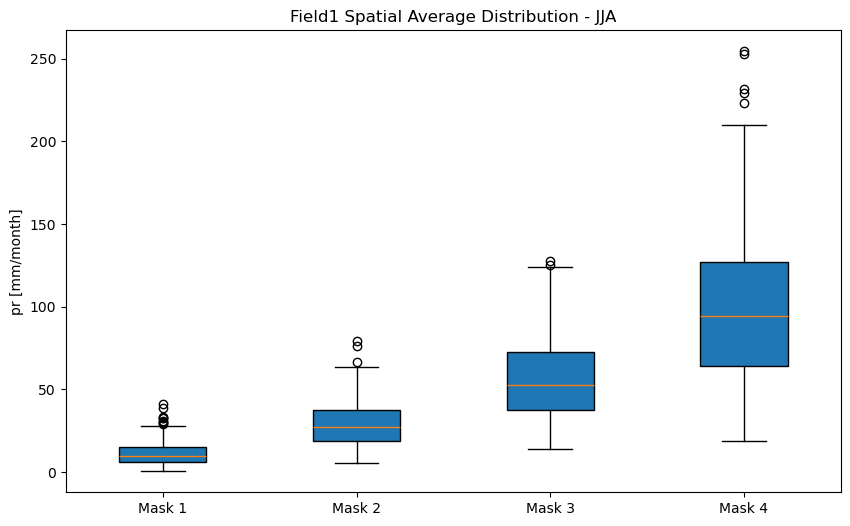

In [50]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))

# Each entry is array of spatial avg values over time for one mask
data = mean_vals_avg_field1_ANN  

ax.boxplot(data, patch_artist=True)
ax.set_xticks(range(1, len(data)+1))
ax.set_xticklabels([f'Mask {i+1}' for i in range(len(data))])
ax.set_title('Field1 Spatial Average Distribution - JJA')
ax.set_ylabel(f'{var} [{units}]')

plt.show()


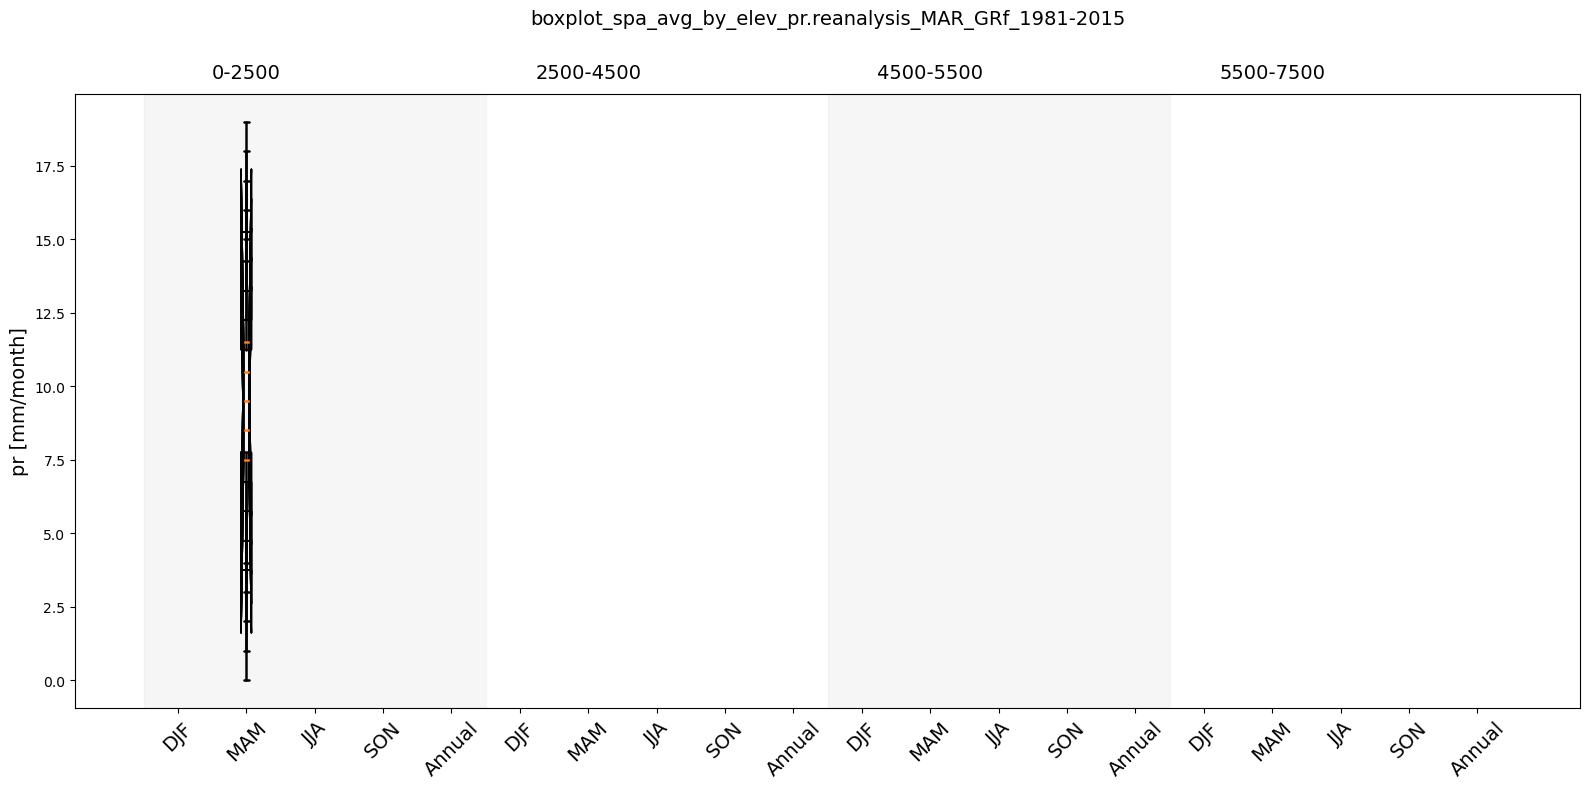

In [51]:
plotname=f'boxplot_spa_avg_by_elev_{var}.reanalysis_MAR_{domain}_{str(iyr)}-{str(fyr)}'

fig, ax = plt.subplots(figsize=(16, 8))
xpos=np.arange(0,20,5)

colorList=['b','orange', 'pink', 'red', 'green', 'black']
markerList=['o','s','^','s','^','s']
faceList=['b','none', 'none', 'none', 'none', 'none']
colors = colorList
elev_labels = ['0-2500', '2500-4500', '4500-5500', '5500-7500']

# Lista con las mean_vals para cada dataset
mean_vals_avg_all_DJF = [mean_vals_avg_field1_DJF, mean_vals_avg_field3_DJF, mean_vals_avg_field4_DJF,
                 mean_vals_avg_field5_DJF, mean_vals_avg_field6_DJF, mean_vals_avg_field7_DJF]

mean_vals_avg_all_MAM = [mean_vals_avg_field1_MAM, mean_vals_avg_field3_MAM, mean_vals_avg_field4_MAM,
                     mean_vals_avg_field5_MAM, mean_vals_avg_field6_MAM, mean_vals_avg_field7_MAM]

mean_vals_avg_all_JJA = [mean_vals_avg_field1_JJA, mean_vals_avg_field3_JJA, mean_vals_avg_field4_JJA,
                     mean_vals_avg_field5_JJA, mean_vals_avg_field6_JJA, mean_vals_avg_field7_JJA]

mean_vals_avg_all_SON = [mean_vals_avg_field1_SON, mean_vals_avg_field3_SON, mean_vals_avg_field4_SON,
                     mean_vals_avg_field5_SON, mean_vals_avg_field6_SON, mean_vals_avg_field7_SON]

mean_vals_avg_all_ANN = [mean_vals_avg_field1_ANN, mean_vals_avg_field3_ANN, mean_vals_avg_field4_ANN,
                     mean_vals_avg_field5_ANN, mean_vals_avg_field6_ANN, mean_vals_avg_field7_ANN]

#for i, mean_vals in enumerate(mean_vals_all_DJF):
#    plt.scatter(xpos, mean_vals, marker=markerList[i],color=colors[i],edgecolor='k',
#                    s=100, label=nameList[i])

for i, mean_vals in enumerate(mean_vals_avg_all_DJF):
    plt.boxplot(xpos, mean_vals)
    
for i, mean_vals in enumerate(mean_vals_avg_all_MAM):
    plt.boxplot(xpos+1, mean_vals)
    
for i, mean_vals in enumerate(mean_vals_avg_all_JJA):
    plt.boxplot(xpos+2, mean_vals)

for i, mean_vals in enumerate(mean_vals_avg_all_SON):
    plt.boxplot(xpos+3, mean_vals)

for i, mean_vals in enumerate(mean_vals_avg_all_ANN):
    plt.boxplot(xpos+4, mean_vals)
    
ax.set_xticks(range(5*4))
ax.set_xticklabels(['DJF','MAM','JJA','SON', 'Annual'] * 4, rotation=45, fontsize=14)
# Background shading every 5 elements
for i in range(0, 20, 5):
    ax.axvspan(i - 0.5, i + 4.5, color='lightgrey' if (i // 5) % 2 == 0 else 'white', alpha=0.2)

ax.set_ylabel(f'{var} [{units}]',fontsize=14)
ax.set_title(plotname,fontsize=14,y=1.1)
#ax.legend()
# Group labels above each triplet
group_labels = elev_labels
for i, label in enumerate(group_labels):
    x_center = i * 5 + 1
    y_pos = ax.get_ylim()[1] * 1.02
    ax.text(x_center, y_pos, label, ha='center', va='bottom', fontsize=14)
plt.tight_layout()

# Save figure (including legend outside)
plt.savefig(plotsDir+plotname+'.png', bbox_inches='tight')


plt.show()

In [52]:
plotname = f'boxplot_spa_avg_by_elev_{var}.reanalysis_MAR_{domain}_{str(iyr)}-{str(fyr)}'

fig, ax = plt.subplots(figsize=(30, 8))
base_xpos = np.arange(0, 20, 5)  # 4 elevation groups spaced by 5

colorList = ['b', 'orange', 'pink', 'red', 'green', 'black']
colors = colorList
elev_labels = ['0-2500', '2500-4500', '4500-5500', '5500-7500']

# Grouped data lists for seasons and datasets (each element is a list of arrays for masks)
seasonal_data_lists = {
    0: mean_vals_avg_all_DJF,
    1: mean_vals_avg_all_MAM,
    2: mean_vals_avg_all_JJA,
    3: mean_vals_avg_all_SON,
    4: mean_vals_avg_all_ANN,
}

width = 0.12  # horizontal offset for boxplots of different datasets within a season

for season_idx, data_list in seasonal_data_lists.items():
    for dataset_idx, data in enumerate(data_list):
        # Calculate positions for each mask in this elevation group, shifted by dataset index
        positions = base_xpos + season_idx + (dataset_idx - 2.5) * width  # centered around season_idx + base_xpos
        
        # data is a list of arrays for masks: plot boxplots for each mask individually, offset by dataset_idx
        # But boxplot expects a list of arrays, each array for a single box.
        # Here, data is already a list of arrays for masks in one dataset
        # So plot all masks for this dataset at their respective positions (one box per mask)
        
        # We assume each data element corresponds to a mask, so plot boxplots at positions accordingly:
        # But positions should match number of boxes (number of masks)
        
        box = ax.boxplot(data,
                         positions=positions,
                         widths=width*0.8,
                         patch_artist=True,
                         manage_ticks=False)
        
        # Color the boxes
        for patch in box['boxes']:
            patch.set_facecolor(colors[dataset_idx])
            patch.set_alpha(0.5)
        # Optionally color whiskers, caps, medians
        for whisker in box['whiskers']:
            whisker.set_color(colors[dataset_idx])
            whisker.set_linewidth(1.5)
        for cap in box['caps']:
            cap.set_color(colors[dataset_idx])
            cap.set_linewidth(1.5)
        for median in box['medians']:
            median.set_color(colors[dataset_idx])
            median.set_linewidth(2)

# Set xticks and labels
ax.set_xticks(base_xpos + 2)  # center label above group (season offset 2 means middle of 0-4)
ax.set_xticklabels(elev_labels, fontsize=14)

# Add group labels for seasons below x axis (like previous)
season_names = ['DJF', 'MAM', 'JJA', 'SON', 'Annual']
for season_idx, name in enumerate(season_names):
    x_center = base_xpos[0] + season_idx + 2  # centered between groups horizontally
    ax.text(x_center, ax.get_ylim()[0] - 0.05*(ax.get_ylim()[1] - ax.get_ylim()[0]),
            name, ha='center', va='top', fontsize=14, transform=ax.get_xaxis_transform())

ax.set_ylabel(f'{var} [{units}]', fontsize=14)
ax.set_title(plotname, fontsize=14, y=1.05)

#plt.tight_layout()
plt.savefig(plotsDir + plotname + '.png', bbox_inches='tight')
plt.show()


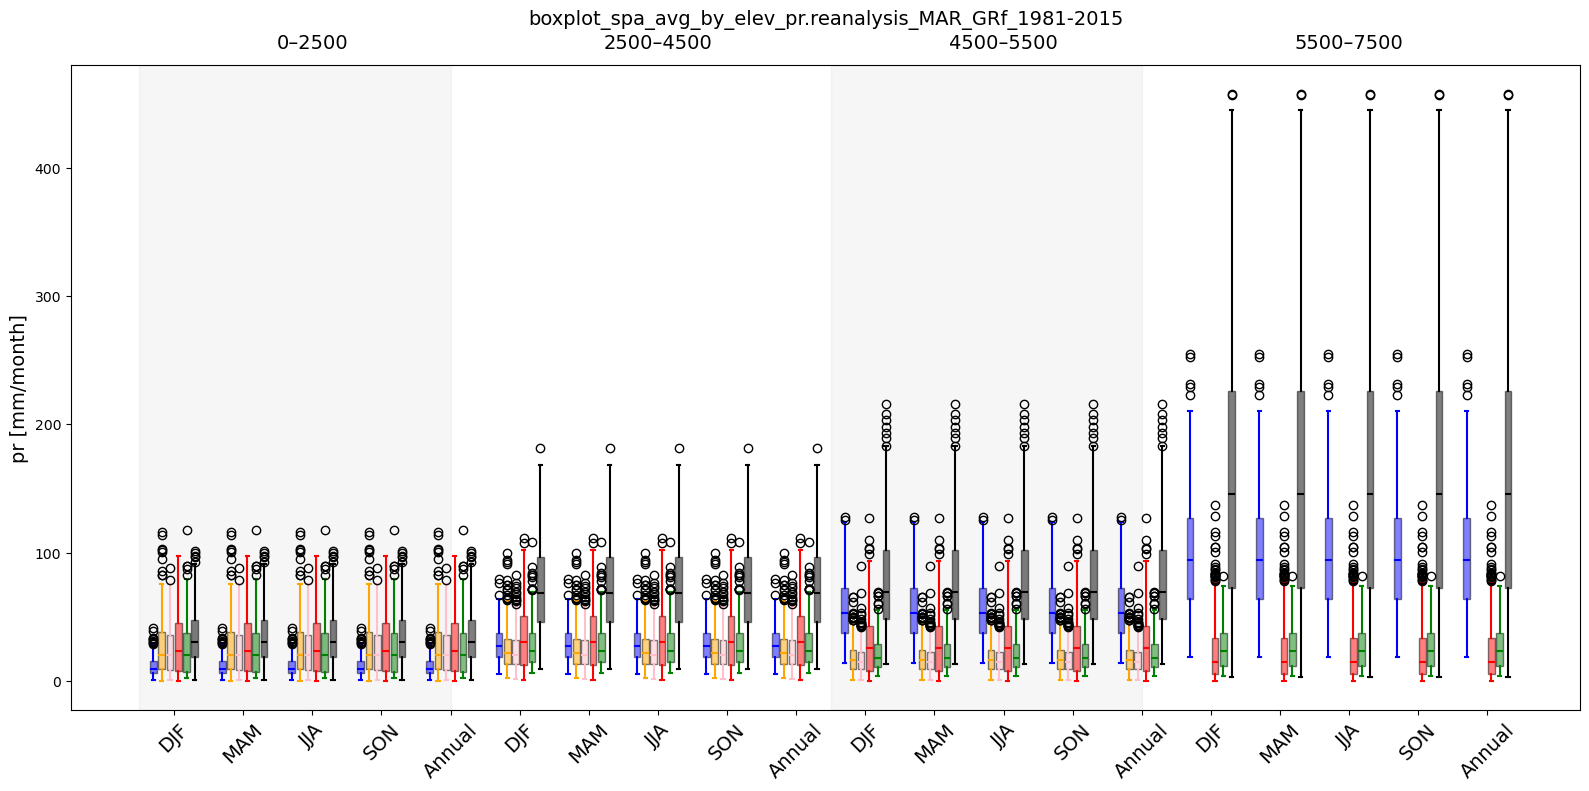

In [53]:
plotname = f'boxplot_spa_avg_by_elev_{var}.reanalysis_MAR_{domain}_{str(iyr)}-{str(fyr)}'

fig, ax = plt.subplots(figsize=(16, 8))
num_elev_groups = 4
num_seasons = 5
width = 0.12

# Base x positions for each group (5 seasons per elevation group)
base_xpos = np.array([i * num_seasons for i in range(num_elev_groups)])

colorList = ['b', 'orange', 'pink', 'red', 'green', 'black']
colors = colorList
elev_labels = ['0–2500', '2500–4500', '4500–5500', '5500–7500']
season_labels = ['DJF', 'MAM', 'JJA', 'SON', 'Annual']

# Grouped data: 5 seasons × 6 datasets × list of 4 mask arrays
seasonal_data_lists = [
    mean_vals_avg_all_DJF,
    mean_vals_avg_all_MAM,
    mean_vals_avg_all_JJA,
    mean_vals_avg_all_SON,
    mean_vals_avg_all_ANN,
]

for elev_idx in range(num_elev_groups):
    xpos_group_start = base_xpos[elev_idx]
    for season_idx, season_data in enumerate(seasonal_data_lists):
        for dataset_idx, dataset_data in enumerate(season_data):
            data = dataset_data[elev_idx]  # 1D array of values for this mask
            xpos = xpos_group_start + season_idx + (dataset_idx - 2.5) * width
            box = ax.boxplot([data],
                             positions=[xpos],
                             widths=width * 0.8,
                             patch_artist=True,
                             manage_ticks=False)
            # Color styling
            for patch in box['boxes']:
                patch.set_facecolor(colors[dataset_idx])
                patch.set_alpha(0.5)
            for elem in ['whiskers', 'caps', 'medians']:
                for item in box[elem]:
                    item.set_color(colors[dataset_idx])
                    item.set_linewidth(1.5)

# Set xticks at center of each season per group
xticks = []
xticklabels = []
for elev_idx in range(num_elev_groups):
    group_start = base_xpos[elev_idx]
    for season_idx in range(num_seasons):
        xticks.append(group_start + season_idx)
        xticklabels.append(season_labels[season_idx])
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45, fontsize=14)

# Background shading every 5-season group (per elevation band)
for elev_idx in range(num_elev_groups):
    start = base_xpos[elev_idx] - 0.5
    end = start + num_seasons
    color = 'lightgrey' if elev_idx % 2 == 0 else 'white'
    ax.axvspan(start, end - 0.5, color=color, alpha=0.2)

# Add elevation group labels above the group
for elev_idx, label in enumerate(elev_labels):
    x_center = base_xpos[elev_idx] + (num_seasons - 1) / 2
    y_pos = ax.get_ylim()[1] * 1.02
    ax.text(x_center, y_pos, label, ha='center', va='bottom', fontsize=14)

ax.set_ylabel(f'{var} [{units}]', fontsize=14)
ax.set_title(plotname, fontsize=14, y=1.05)

plt.tight_layout()
plt.savefig(plotsDir + plotname + '.png', bbox_inches='tight')
plt.show()
